In [1]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [2]:

#Ahora importamos nuestra capa creada que vamos a analizar en este proyecto siendo la que tiene el polinomio de Legendre

class PolynomialLegendre(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialLegendre, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # El kernel debe cubrir (grado + 1) si incluyes P0, o (grado) si empiezas en P1
        # Aquí usaremos desde P1 hasta P_degree
        self.kernel = self.add_weight(
            shape=(input_dim * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias"
            )

    def call(self, inputs):
        # Aseguramos que los inputs sean float32
        x = tf.cast(inputs, self.compute_dtype)
        
        # P0 = 1, P1 = x
        p_nm2 = tf.ones_like(x)
        p_nm1 = x
        
        features = [p_nm1] # Empezamos con grado 1

        for n in range(2, self.degree + 1):
            n_float = tf.cast(n, self.compute_dtype)
            # Fórmula de recurrencia de Legendre
            p_n = ((2.0 * n_float - 1.0) * x * p_nm1 - (n_float - 1.0) * p_nm2) / n_float
            features.append(p_n)
            
            p_nm2 = p_nm1
            p_nm1 = p_n

        # Concatenamos: (batch, input_dim * degree)
        # Esto genera: [x_poly1, x_poly2, ..., x_poly_degree]
        phi = tf.concat(features, axis=-1)

        output = tf.matmul(phi, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output
    


In [3]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    


In [4]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)


In [5]:
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = PolynomialLegendre(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
#Parametros para el entrenamiento
degree = 8
epochs = 120


In [7]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
print("Entrenando Grado" + str(degree) + " ...")
modeloTest = PolynomialDenseCreator(degree)
history = modeloTest.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)



Entrenando Grado7 ...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8147 - loss: 0.4217 - val_accuracy: 0.8509 - val_loss: 0.3646
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8506 - loss: 0.3549 - val_accuracy: 0.8367 - val_loss: 0.3711
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8580 - loss: 0.3424 - val_accuracy: 0.8591 - val_loss: 0.3454
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8601 - loss: 0.3359 - val_accuracy: 0.8640 - val_loss: 0.3335
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8614 - loss: 0.3298 - val_accuracy: 0.8650 - val_loss: 0.3294
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8637 - loss: 0.3268 - val_accuracy: 0.8627 - val_loss: 0.3301
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8658 - loss: 0.3225 - val_accuracy: 0.8607 - val_loss: 0.3234
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8668 - 


RESULTADOS FINALES (Grado 7)
Acurracy en test: 0.87408


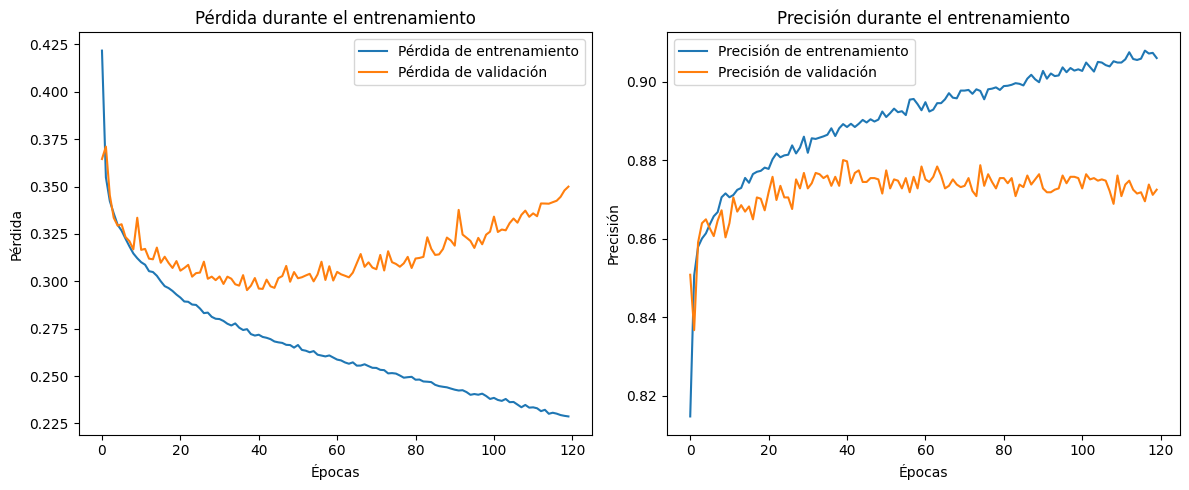

In [8]:
print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree})")
print("Acurracy en test: {:.5f}".format(modeloTest.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history)